# Muziekclassificatie -- Drempelwaarde-model

**Project R.E.M. -- Notebook 3 van 4**

> **Let op:** Ondanks de naam 'Supervised' is dit **geen getraind machine learning-model**.
> Dit notebook past een **deterministische drempelwaarde-classificatie** toe op basis van
> een handgemaakte arousal-score formule. Er vindt geen fitting op labelled data plaats;
> de drempelwaarden zijn door de onderzoeker ingesteld, niet geleerd van de data.

## Doel

Classificeert nummers uit de Spotify-bibliotheek van deelnemers als **CALM**, **ENERGY** of **OTHER**
op basis van een gewogen arousal-score berekend uit Spotify audio-kenmerken.

**Onderzoeksvraag (RQ5, deels):** *Kunnen we elk nummer in de bibliotheek van een deelnemer
automatisch classificeren voor playlistgeneratie, voorbij handmatige BPM/energy-drempels?*

## Aanpak

1. **Voorfilter** -- verwijder live-opnames (liveness > 0.80) en gesproken-woord tracks (speechiness > 0.66)
2. **Normalisatie** -- MinMaxScaler per deelnemer zodat elk kenmerk het bereik [0,1] krijgt
3. **Arousal-score** -- gewogen som van audio-kenmerken:
   ```
   arousal = 0.35 x energy + 0.30 x tempo + 0.20 x loudness - 0.10 x acousticness + 0.05 x danceability
   ```
4. **Classificatie** -- drempelwaarden op de arousal-score + valence-vloer voor CALM

## Waarom per-deelnemer normalisatie?

De muziekbibliotheek van elke deelnemer heeft een uniek audio-featurebereik
(bijv. iemand die alleen elektronische muziek luistert heeft andere min/max tempo dan een klassiekluisteraar).
Per-deelnemer MinMaxScaler zorgt dat de drempelwaarden dezelfde relatieve betekenis hebben
voor elk individu. **Gevolg: nummers zijn niet vergelijkbaar over deelnemers heen** na normalisatie;
een hoge arousal-score voor deelnemer A kan een ander absoluut BPM betekenen dan voor B.

Zie: [sklearn MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

## Gebruik

| Instelling | Betekenis |
|---|---|
| `REUSE_MODEL = False` | Fit nieuwe scaler en sla op (aanbevolen bij nieuwe deelnemers) |
| `REUSE_MODEL = True` | Laad bestaande scaler vanuit `models/music_classification/` |

**Vereiste:** voor elk deelnemer moet `data/playlists/{codename}/playlists_generated/combined.csv`
bestaan (gegenereerd door `uv run python scripts/playlists/spotify_cli.py prepare {codename}`).

In [1]:
from __future__ import annotations

import json
import math
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## Configuratie

In [ ]:
# REUSE_MODEL: True  -> laad bestaande scaler (snel)
#              False -> fit nieuwe scaler en sla op
REUSE_MODEL = False

# PARTICIPANT: 'all' -> alle deelnemers automatisch detecteren
#              string -> bijv. 'peer'
PARTICIPANT = 'all'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paden
PROJECT_ROOT  = Path().resolve().parent.parent
PLAYLISTS_DIR = PROJECT_ROOT / 'data' / 'playlists'
ANALYSIS_DIR  = PROJECT_ROOT / 'data' / 'analysis'
MODELS_DIR    = PROJECT_ROOT / 'models' / 'music_classification'

# Audio-kenmerken die worden gebruikt voor scoring
SCORING_FEATURES = [
    'tempo', 'energy', 'loudness', 'valence',
    'danceability', 'acousticness', 'instrumentalness', 'speechiness',
]

# Gewichten voor arousal-score (positief = verhoogt arousal, negatief = verlaagt)
# Gewichten zijn gebaseerd op muziekpsychologisch onderzoek naar arousaldimensies.
AROUSAL_WEIGHTS = {
    'energy':       0.35,
    'tempo':        0.30,
    'loudness':     0.20,
    'acousticness': -0.10,
    'danceability': 0.05,
}

# Voorfilter-drempels (gebaseerd op Spotify API-documentatie)
SPEECHINESS_MAX = 0.66   # > 0.66 = gesproken woord / podcast
LIVENESS_MAX    = 0.80   # > 0.80 = hoge kans op live-opname

# Classificatiedrempels
CALM_THRESHOLD   = 0.35
ENERGY_THRESHOLD = 0.65
VALENCE_FLOOR    = 0.25  # CALM-nummers moeten positief genoeg zijn (geen droeve muziek)

# Visuele stijl (donker thema, consistent met Shiny-app)
DARK = {
    'figure.facecolor': '#0f1218', 'axes.facecolor': '#181e2a',
    'axes.edgecolor': '#4a5568', 'axes.labelcolor': '#e2e8f0',
    'xtick.color': '#e2e8f0', 'ytick.color': '#e2e8f0',
    'text.color': '#e2e8f0', 'grid.color': '#2d3748', 'grid.alpha': 0.5,
    'font.family': 'monospace', 'legend.facecolor': '#1a2035',
    'legend.edgecolor': '#4a5568',
}
plt.rcParams.update(DARK)
plt.rcParams['figure.dpi'] = 120

# Okabe-Ito kleuren per klasse (kleurenblind-vriendelijk)
CLASS_COLORS = {'calm': '#56b4e9', 'energy': '#e69f00', 'other': '#999999'}
CLASS_ORDER  = ['calm', 'energy', 'other']

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'REUSE_MODEL  : {REUSE_MODEL}')
print(f'PARTICIPANT  : {PARTICIPANT}')

PROJECT_ROOT : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project
REUSE_MODEL  : False
PARTICIPANT  : all


## 1. Data laden

In [3]:
def load_combined(codename: str) -> pd.DataFrame:
    """Laad combined.csv (alle Spotify-nummers) voor een deelnemer."""
    path = PLAYLISTS_DIR / codename / 'playlists_generated' / 'combined.csv'
    if not path.exists():
        raise FileNotFoundError(
            f"Invoerbestand niet gevonden voor '{codename}'.\n"
            f"Verwacht: {path}\n"
            f"Voer eerst uit: uv run python scripts/playlists/spotify_cli.py prepare {codename}"
        )
    df = pd.read_csv(path)
    df['participant'] = codename
    return df


def detect_participants() -> list[str]:
    """Detecteer alle deelnemers met een combined.csv."""
    return sorted(
        d.name for d in PLAYLISTS_DIR.iterdir()
        if d.is_dir() and (d / 'playlists_generated' / 'combined.csv').exists()
    )


if PARTICIPANT == 'all':
    participants = detect_participants()
    if not participants:
        raise FileNotFoundError(
            f'Geen combined.csv gevonden onder {PLAYLISTS_DIR}.\n'
            'Verwerk eerst de playlists met de spotify_cli.py pipeline.'
        )
else:
    participants = [PARTICIPANT]

frames: dict[str, pd.DataFrame] = {}
for codename in participants:
    df_raw = load_combined(codename)
    frames[codename] = df_raw
    print(f'  {codename}: {len(df_raw)} nummers geladen')

print(f'\nTotaal: {len(participants)} deelnemer(s)')

  courgette: 5720 nummers geladen
  peer: 691 nummers geladen
  watermeloen: 620 nummers geladen

Totaal: 3 deelnemer(s)


## 2. Validatie & Voorverwerking

Live-opnames en gesproken-woord tracks worden gefilterd op basis van Spotify's
`liveness` en `speechiness` scores. Deze tracks verstoren de arousal-score
omdat ze andere audio-eigenschappen hebben dan studio-opnames.

In [4]:
def validate_and_clean(df: pd.DataFrame, codename: str) -> pd.DataFrame:
    """Controleer vereiste kolommen, verwijder duplicaten en NaN-rijen."""
    required = SCORING_FEATURES + ['liveness']
    missing_cols = [c for c in required if c not in df.columns]
    if missing_cols:
        raise ValueError(f'[{codename}] Ontbrekende kolommen: {missing_cols}')

    if 'uri' in df.columns:
        n_dupes = df.duplicated(subset=['uri'], keep='first').sum()
        df = df.drop_duplicates(subset=['uri'], keep='first').copy()
    else:
        n_dupes = df.duplicated(subset=['name', 'artists'], keep='first').sum()
        df = df.drop_duplicates(subset=['name', 'artists'], keep='first').copy()

    n_before = len(df)
    df = df.dropna(subset=required).copy()
    n_nan = n_before - len(df)
    print(f'  {codename}: {len(df)} unieke nummers ({n_dupes} duplicaten, {n_nan} NaN-rijen verwijderd)')
    return df


def prefilter(df: pd.DataFrame, codename: str) -> pd.DataFrame:
    """Verwijder live-opnames (liveness > 0.80) en gesproken-woord (speechiness > 0.66)."""
    speech_mask = df['speechiness'] > SPEECHINESS_MAX
    live_mask   = df['liveness']    > LIVENESS_MAX
    n_removed   = (speech_mask | live_mask).sum()
    df = df[~speech_mask & ~live_mask].copy()
    if n_removed:
        print(f'  {codename}: {n_removed} tracks gefilterd ({speech_mask.sum()} speech, {live_mask.sum()} live)')
    return df


cleaned: dict[str, pd.DataFrame] = {}
for codename, df_raw in frames.items():
    df = validate_and_clean(df_raw, codename)
    df = prefilter(df, codename)
    cleaned[codename] = df

print('\nVoorverwerking voltooid.')

  courgette: 5720 unieke nummers (0 duplicaten, 0 NaN-rijen verwijderd)
  peer: 691 unieke nummers (0 duplicaten, 0 NaN-rijen verwijderd)
  watermeloen: 620 unieke nummers (0 duplicaten, 0 NaN-rijen verwijderd)

Voorverwerking voltooid.


## 3. Normalisatie & Arousal-score

**Waarom MinMaxScaler?**
Elke genormaliseerde waarde wordt een percentage van het bereik van dat kenmerk in de bibliotheek
van die specifieke deelnemer. De gewichten betekenen dan letterlijk:
'35% van het volledige energy-bereik van deze persoon draagt bij aan de score.'

**Arousal-scoreformule (op genormaliseerde [0,1]-kenmerken):**
```
arousal = 0.35 x energy + 0.30 x tempo + 0.20 x loudness - 0.10 x acousticness + 0.05 x danceability
```

**Classificatieregels:**
- `arousal < 0.35` EN `valence >= 0.25` -> **CALM** (laag arousal, niet te droef)
- `arousal > 0.65` -> **ENERGY** (hoog arousal)
- Al het overige -> **OTHER** (middengebied, opvangnet)

De valence-vloer voor CALM voorkomt dat droeve, rustige muziek als CALM wordt geclassificeerd --
voor stressreductie is positive valence wenselijk.

In [5]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)


def fit_or_load_scaler(codename: str, X: np.ndarray) -> MinMaxScaler:
    """Fit een nieuwe MinMaxScaler of laad een bestaande."""
    scaler_path = MODELS_DIR / f'{codename}_scaler.pkl'
    if REUSE_MODEL:
        if not scaler_path.exists():
            raise FileNotFoundError(
                f'REUSE_MODEL=True maar scaler niet gevonden: {scaler_path}\n'
                'Zet REUSE_MODEL=False en voer het notebook opnieuw uit.'
            )
        scaler = joblib.load(scaler_path)
        print(f'  {codename}: scaler geladen vanuit {scaler_path.name}')
    else:
        scaler = MinMaxScaler()
        scaler.fit(X)
        joblib.dump(scaler, scaler_path)
        print(f'  {codename}: scaler gefittet en opgeslagen -> {scaler_path.name}')
    return scaler


def classify_pipeline(
    df: pd.DataFrame,
    codename: str,
    calm_threshold: float = CALM_THRESHOLD,
    energy_threshold: float = ENERGY_THRESHOLD,
    valence_floor: float = VALENCE_FLOOR,
) -> tuple:
    """
    Volledige classificatiepipeline voor een deelnemer.
    Retourneert (df_met_klassen, df_genormaliseerd, scaler).
    """
    X = df[SCORING_FEATURES].values
    scaler = fit_or_load_scaler(codename, X)

    X_scaled  = scaler.transform(X)
    df_scaled = pd.DataFrame(X_scaled, columns=SCORING_FEATURES, index=df.index)

    df = df.copy()
    df['arousal_score'] = sum(
        weight * df_scaled[feat] for feat, weight in AROUSAL_WEIGHTS.items()
    )

    def classify(arousal: float, valence_norm: float) -> str:
        if arousal < calm_threshold and valence_norm >= valence_floor:
            return 'calm'
        elif arousal > energy_threshold:
            return 'energy'
        return 'other'

    df['class'] = [
        classify(a, v)
        for a, v in zip(df['arousal_score'], df_scaled['valence'])
    ]

    return df, df_scaled, scaler


results: dict = {}
for codename, df in cleaned.items():
    df_classified, df_scaled, scaler = classify_pipeline(df, codename)
    results[codename] = (df_classified, df_scaled, scaler)

print('\nClassificatie voltooid.')

  courgette: scaler gefittet en opgeslagen -> courgette_scaler.pkl
  peer: scaler gefittet en opgeslagen -> peer_scaler.pkl
  watermeloen: scaler gefittet en opgeslagen -> watermeloen_scaler.pkl

Classificatie voltooid.


## 4. Opslaan

Sla geclassificeerde nummers en config op. De Shiny-app en playlist-generator lezen `classified_songs.csv`.

In [6]:
# classified_songs.csv per deelnemer
internal_cols = {'kmeans_cluster', 'kmeans_label', 'gmm_cluster', 'gmm_label', 'gmm_confidence'}

for codename, (df_c, _, _) in results.items():
    out_dir = ANALYSIS_DIR / codename
    out_dir.mkdir(parents=True, exist_ok=True)
    save_cols = [c for c in df_c.columns if c not in internal_cols]
    csv_path = out_dir / 'classified_songs.csv'
    df_c[save_cols].to_csv(csv_path, index=False)
    print(f'  {codename}: {len(df_c)} nummers -> {csv_path.relative_to(PROJECT_ROOT)}')

# Config per deelnemer (drempelwaarden + klasseverdeling)
for codename, (df_c, _, _) in results.items():
    counts = df_c['class'].value_counts()
    config = {
        'created':            datetime.now().isoformat(),
        'participant':        codename,
        'n_songs_total':      len(frames[codename]),
        'n_songs_classified': len(df_c),
        'scoring_features':   SCORING_FEATURES,
        'arousal_weights':    AROUSAL_WEIGHTS,
        'thresholds': {
            'calm':          CALM_THRESHOLD,
            'energy':        ENERGY_THRESHOLD,
            'valence_floor': VALENCE_FLOOR,
        },
        'pre_filters': {
            'speechiness_max': SPEECHINESS_MAX,
            'liveness_max':    LIVENESS_MAX,
        },
        'class_distribution': {
            cls: int(counts.get(cls, 0)) for cls in ['calm', 'energy', 'other']
        },
    }
    config_path = MODELS_DIR / f'{codename}_config.json'
    with open(config_path, 'w', encoding='utf-8') as f:
        json.dump(config, f, indent=2)
    print(f'  {codename}: config -> {config_path.name}')

print('\nKlaar.')

  courgette: 5720 nummers -> data\analysis\courgette\classified_songs.csv
  peer: 691 nummers -> data\analysis\peer\classified_songs.csv
  watermeloen: 620 nummers -> data\analysis\watermeloen\classified_songs.csv
  courgette: config -> courgette_config.json
  peer: config -> peer_config.json
  watermeloen: config -> watermeloen_config.json

Klaar.


---

## 5. Diagnostiek

### 5a. Klasseverdeling (tabel)

Een grote OTHER-klasse is normaal -- die is bedoeld als opvangnet voor muziek
die niet duidelijk calm of energetisch is. CALM en ENERGY zijn de relevante pools
voor playlistgeneratie.

In [7]:
print(f"{'Deelnemer':<14} {'CALM':>8} {'ENERGY':>8} {'OTHER':>8} {'Totaal':>8}")
print('-' * 42)
for codename, (df_c, _, _) in results.items():
    counts = df_c['class'].value_counts()
    n_calm   = counts.get('calm', 0)
    n_energy = counts.get('energy', 0)
    n_other  = counts.get('other', 0)
    total    = len(df_c)
    print(f'{codename:<14} {n_calm:>7} {n_energy:>8} {n_other:>8} {total:>8}')
    for cls, n in [('calm', n_calm), ('energy', n_energy)]:
        if n / total < 0.05:
            print(f'  Let op: {cls.upper()} < 5% -- overweeg drempelwaarden aan te passen')

Deelnemer          CALM   ENERGY    OTHER   Totaal
------------------------------------------
courgette          566      737     4417     5720
peer                53       96      542      691
watermeloen         25      103      492      620
  Let op: CALM < 5% -- overweeg drempelwaarden aan te passen


### 5a-bis. Lage CALM-deelnemer diagnostiek

Watermeloen heeft slechts 4.0% CALM — de laagste van de huidige deelnemers. De cel hieronder
vergelijkt de verdeling van de arousal-score voor de laagste CALM-deelnemer met het gemiddelde
van alle anderen. Als de verdeling naar rechts verschoven is (hogere arousal), dan is de
35%-drempel te laag voor die bibliotheek na per-deelnemer normalisatie.

> **Let op:** De onderliggende code is specifiek voor `citroen` (niet aanwezig in de huidige run).
> Wanneer citroen wordt toegevoegd, wordt dit diagram automatisch opgebouwd.

In [8]:
if 'citroen' in results:
    print("Arousal-score statistieken per deelnemer (vergelijking):\n")
    rows = []
    for codename, (df_c, _, _) in results.items():
        a = df_c['arousal_score']
        rows.append({
            'deelnemer':  codename,
            'gem':        round(a.mean(), 3),
            'mediaan':    round(a.median(), 3),
            'std':        round(a.std(), 3),
            '% < 0.35':  round((a < CALM_THRESHOLD).mean() * 100, 1),
            '% > 0.65':  round((a > ENERGY_THRESHOLD).mean() * 100, 1),
        })
    diag_df = pd.DataFrame(rows).sort_values('gem')
    display(diag_df)

    # Overlay histogram: citroen vs gemiddelde van alle anderen
    other_arousal = pd.concat(
        [df_c['arousal_score'] for p, (df_c, _, _) in results.items() if p != 'citroen'],
        ignore_index=True,
    )
    citroen_arousal = results['citroen'][0]['arousal_score']

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(other_arousal, bins=40, density=True, alpha=0.5,
            color='#56b4e9', label='Overige deelnemers (gem.)')
    ax.hist(citroen_arousal, bins=40, density=True, alpha=0.7,
            color='#e69f00', label='citroen')
    ax.axvline(CALM_THRESHOLD,   color='#56b4e9', linestyle='--', linewidth=1.5,
               label=f'Calm-drempel ({CALM_THRESHOLD})')
    ax.axvline(ENERGY_THRESHOLD, color='#e69f00', linestyle='--', linewidth=1.5,
               label=f'Energy-drempel ({ENERGY_THRESHOLD})')
    ax.set_xlabel('Arousal-score (na per-deelnemer normalisatie)')
    ax.set_ylabel('Dichtheid')
    ax.set_title('Citroen vs. overige deelnemers — arousal-score verdeling')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    med_diff = citroen_arousal.median() - other_arousal.median()
    if abs(med_diff) > 0.05:
        direction = 'hoger' if med_diff > 0 else 'lager'
        print(f"\nCitroen mediaan arousal {direction} dan overige deelnemers "
              f"(Δ={med_diff:+.3f}). "
              f"{'Dit verklaart de lage CALM-fractie.' if med_diff > 0 else 'Dit wijst op een acoustisch/rustig bibliotheek.'}")
    else:
        print("\nGeen significante verschuiving in citroen's arousaldistributie.")
        print("De lage CALM-fractie kan een gevolg zijn van de valence-vloer (>=0.25).")
else:
    print("Citroen niet aanwezig in huidige deelnemersset.")

Citroen niet aanwezig in huidige deelnemersset.


### 5b. Klasseverdeling (gestapeld staafdiagram)

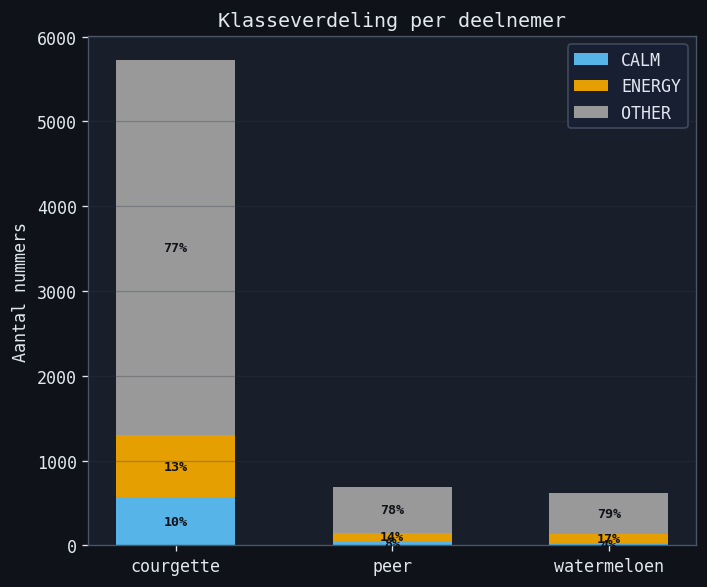

In [9]:
fig, ax = plt.subplots(figsize=(max(6, len(participants) * 2), 5))

x      = np.arange(len(participants))
bottom = np.zeros(len(participants))

for cls in CLASS_ORDER:
    counts = [(results[p][0]['class'] == cls).sum() for p in participants]
    bars = ax.bar(x, counts, bottom=bottom, color=CLASS_COLORS[cls],
                  label=cls.upper(), width=0.55, edgecolor='none')
    totals = [len(results[p][0]) for p in participants]
    for i, (bar, count, total) in enumerate(zip(bars, counts, totals)):
        pct = count / total * 100
        if pct > 4:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + count / 2,
                f'{pct:.0f}%',
                ha='center', va='center', fontsize=8, color='#0f1218', fontweight='bold',
            )
    bottom += np.array(counts, dtype=float)

ax.set_xticks(x)
ax.set_xticklabels(participants)
ax.set_ylabel('Aantal nummers')
ax.set_title('Klasseverdeling per deelnemer')
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5c. Gemiddelde kenmerken per klasse

In [10]:
for codename, (df_c, _, _) in results.items():
    print(f"\n{'='*65}")
    print(f'  {codename} -- gemiddelde kenmerken per klasse')
    print(f"{'='*65}")
    means = (
        df_c.groupby('class')[SCORING_FEATURES + ['arousal_score']]
        .mean()
        .round(3)
        .reindex(['calm', 'energy', 'other'])
    )
    display(means)


  courgette -- gemiddelde kenmerken per klasse


,tempo,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness,arousal_score
class,,,,,,,,,
calm,103.179,0.202,-18.368,0.433,0.512,0.856,0.407,0.050,0.230
energy,148.313,0.893,-4.892,0.581,0.555,0.042,0.083,0.084,0.692
other,114.647,0.526,-10.899,0.447,0.569,0.395,0.206,0.059,0.444



  peer -- gemiddelde kenmerken per klasse


,tempo,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness,arousal_score
class,,,,,,,,,
calm,103.002,0.305,-11.674,0.428,0.560,0.796,0.094,0.054,0.277
energy,152.105,0.876,-4.605,0.548,0.503,0.049,0.039,0.087,0.705
other,115.778,0.526,-8.816,0.364,0.544,0.405,0.107,0.049,0.442



  watermeloen -- gemiddelde kenmerken per klasse


,tempo,energy,loudness,valence,danceability,acousticness,instrumentalness,speechiness,arousal_score
class,,,,,,,,,
calm,94.993,0.405,-11.726,0.436,0.669,0.519,0.485,0.072,0.287
energy,150.122,0.925,-4.742,0.485,0.569,0.022,0.173,0.093,0.703
other,119.709,0.693,-7.992,0.415,0.657,0.134,0.395,0.064,0.517


### 5d. Arousal-score verdeling

Een goede classificatie geeft duidelijk gescheiden pieken voor CALM (links) en ENERGY (rechts).
Grote overlap tussen CALM en OTHER is normaal -- de valence-vloer heeft er al voor gefilterd.

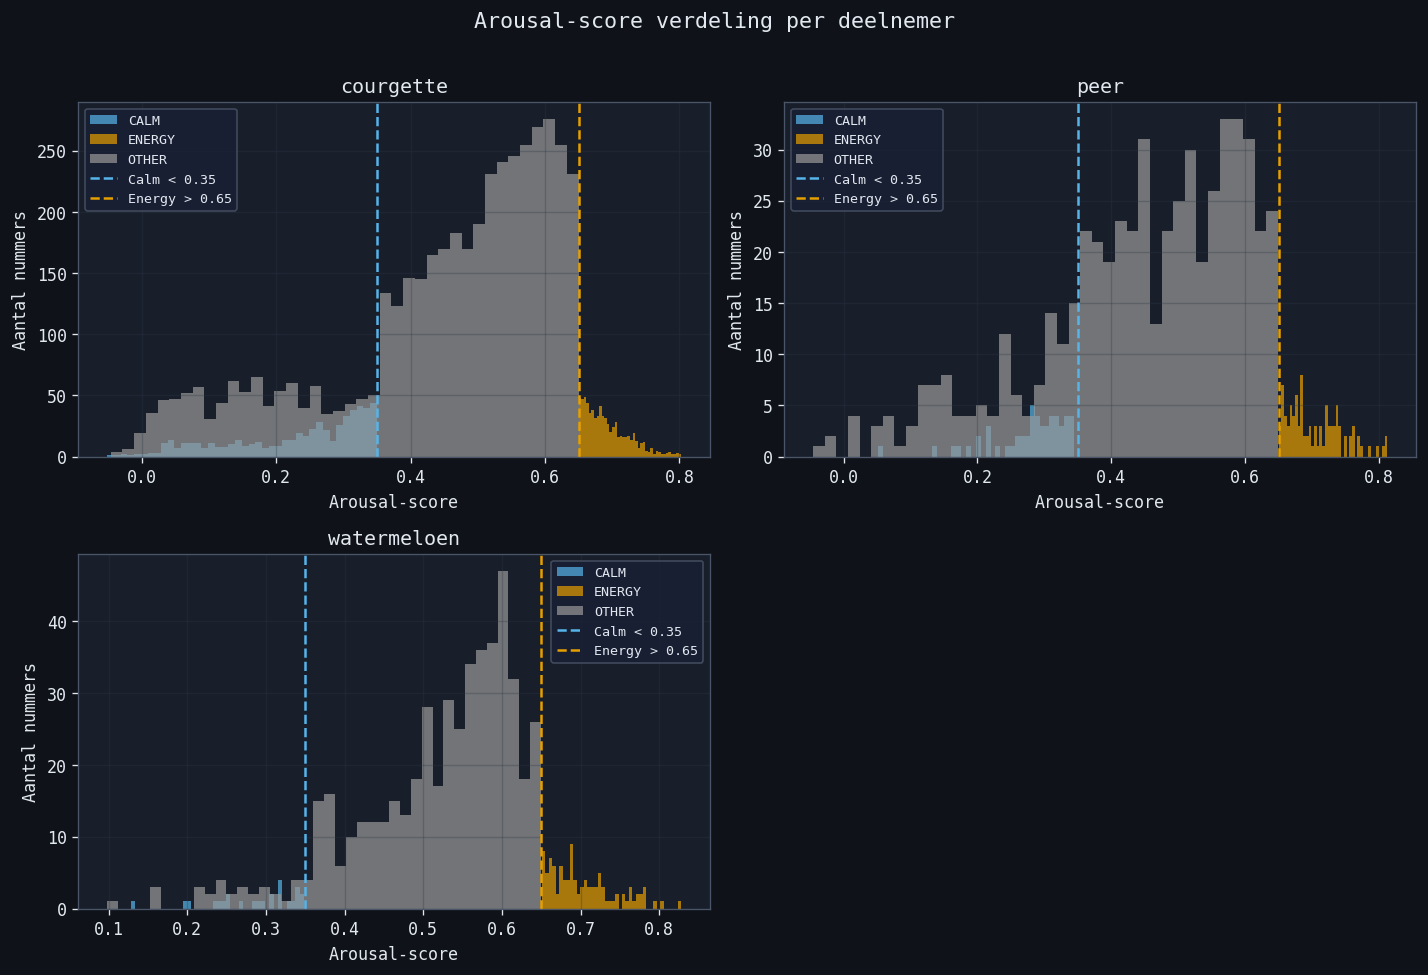

In [11]:
n_cols = min(2, len(results))
n_rows = (len(results) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), squeeze=False)

for idx, (codename, (df_c, _, _)) in enumerate(results.items()):
    ax = axes[idx // n_cols][idx % n_cols]
    for cls in CLASS_ORDER:
        subset = df_c[df_c['class'] == cls]['arousal_score']
        ax.hist(subset, bins=40, color=CLASS_COLORS[cls], alpha=0.7,
                label=cls.upper(), edgecolor='none')
    ax.axvline(CALM_THRESHOLD, color='#56b4e9', linestyle='--',
               linewidth=1.5, label=f'Calm < {CALM_THRESHOLD}')
    ax.axvline(ENERGY_THRESHOLD, color='#e69f00', linestyle='--',
               linewidth=1.5, label=f'Energy > {ENERGY_THRESHOLD}')
    ax.set_title(codename)
    ax.set_xlabel('Arousal-score')
    ax.set_ylabel('Aantal nummers')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for idx in range(len(results), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.suptitle('Arousal-score verdeling per deelnemer', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5e. Drempelwaarde-gevoeligheidsanalyse

Sweept calm- en energy-drempels om te zien hoe de klasseverdeling verschuift.
Helpt bij het vinden van stabiele drempelgebieden die robuust zijn voor kleine parameterwijzigingen.

In [12]:
calm_range   = np.arange(0.25, 0.46, 0.05)
energy_range = np.arange(0.55, 0.76, 0.05)

for codename, (df_c, df_scaled, _) in results.items():
    sweep_rows = []
    for ct in calm_range:
        for et in energy_range:
            if ct >= et:
                continue
            labels = [
                'calm'   if a < ct and v >= VALENCE_FLOOR else
                'energy' if a > et else 'other'
                for a, v in zip(df_c['arousal_score'], df_scaled['valence'])
            ]
            n_total = len(labels)
            sweep_rows.append({
                'calm_thresh':   round(ct, 2),
                'energy_thresh': round(et, 2),
                'n_calm':        labels.count('calm'),
                'pct_calm':      round(labels.count('calm') / n_total * 100, 1),
                'n_energy':      labels.count('energy'),
                'pct_energy':    round(labels.count('energy') / n_total * 100, 1),
                'n_other':       labels.count('other'),
            })

    sweep_df = pd.DataFrame(sweep_rows)
    print(f'\n{codename} -- drempelwaarde-sweep (top 10 op n_calm)')
    display(sweep_df.sort_values('n_calm', ascending=False).head(10).reset_index(drop=True))

    current = sweep_df[
        (sweep_df['calm_thresh']   == round(CALM_THRESHOLD, 2)) &
        (sweep_df['energy_thresh'] == round(ENERGY_THRESHOLD, 2))
    ]
    if not current.empty:
        print(f'  Huidige instellingen (calm={CALM_THRESHOLD}, energy={ENERGY_THRESHOLD}):')
        display(current.reset_index(drop=True))


courgette -- drempelwaarde-sweep (top 10 op n_calm)


,calm_thresh,energy_thresh,n_calm,pct_calm,n_energy,pct_energy,n_other
0,0.45,0.60,1158,20.2,1455,25.4,3107
1,0.45,0.75,1158,20.2,47,0.8,4515
2,0.45,0.70,1158,20.2,254,4.4,4308
3,0.45,0.65,1158,20.2,737,12.9,3825
4,0.45,0.55,1158,20.2,2211,38.7,2351
5,0.40,0.60,832,14.5,1455,25.4,3433
6,0.40,0.75,832,14.5,47,0.8,4841
7,0.40,0.55,832,14.5,2211,38.7,2677
8,0.40,0.65,832,14.5,737,12.9,4151
9,0.40,0.70,832,14.5,254,4.4,4634


  Huidige instellingen (calm=0.35, energy=0.65):


,calm_thresh,energy_thresh,n_calm,pct_calm,n_energy,pct_energy,n_other
0,0.35,0.65,566,9.9,737,12.9,4417



peer -- drempelwaarde-sweep (top 10 op n_calm)


...

,calm_thresh,energy_thresh,n_calm,pct_calm,n_energy,pct_energy,n_other
0,0.35,0.65,53,7.7,96,13.9,542



watermeloen -- drempelwaarde-sweep (top 10 op n_calm)


,calm_thresh,energy_thresh,n_calm,pct_calm,n_energy,pct_energy,n_other
0,0.45,0.60,70,11.3,204,32.9,346
1,0.45,0.75,70,11.3,17,2.7,533
2,0.45,0.70,70,11.3,46,7.4,504
3,0.45,0.65,70,11.3,103,16.6,447
4,0.45,0.55,70,11.3,338,54.5,212
5,0.40,0.60,49,7.9,204,32.9,367
6,0.40,0.75,49,7.9,17,2.7,554
7,0.40,0.55,49,7.9,338,54.5,233
8,0.40,0.65,49,7.9,103,16.6,468
9,0.40,0.70,49,7.9,46,7.4,525


  Huidige instellingen (calm=0.35, energy=0.65):


,calm_thresh,energy_thresh,n_calm,pct_calm,n_energy,pct_energy,n_other
0,0.35,0.65,25,4.0,103,16.6,492


### 5f. Spot-check -- 10 willekeurige nummers per klasse

Meest directe validatie: kloppen de nummers qua gevoel met hun klasse?
CALM-nummers moeten rustig en akoestisch aanvoelen; ENERGY-nummers snel en luid.

In [13]:
spot_cols_base = ['name', 'artists', 'tempo', 'energy', 'valence', 'loudness', 'arousal_score', 'class']

for codename, (df_c, _, _) in results.items():
    spot_cols = [c for c in spot_cols_base if c in df_c.columns]
    print(f"\n{'='*70}")
    print(f'  {codename} -- spot-check')
    print(f"{'='*70}")
    for cls in ['calm', 'energy', 'other']:
        subset = df_c[df_c['class'] == cls]
        n_show = min(10, len(subset))
        print(f'\n  {cls.upper()} ({n_show} van {len(subset)} nummers)')
        display(subset[spot_cols].sample(n_show, random_state=RANDOM_STATE).reset_index(drop=True))


  courgette -- spot-check

  CALM (10 van 566 nummers)


,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,If You Love Her,Forest Blakk,50.827,0.4450,0.278,-8.087,0.301001,calm
1,At Last,Etta James,87.430,0.3480,0.328,-8.631,0.310634,calm
2,Taste,Jonka Tribute,112.974,0.1100,0.459,-18.928,0.213832,calm
3,(You Make Me Feel Like) A Natural Woman,Aretha Franklin,110.890,0.2710,0.405,-10.083,0.324525,calm
4,Lopen Tot De Zon Komt,Acda en de Munnik,98.811,0.3280,0.356,-9.079,0.296804,calm
5,Sera,Carluccio,74.296,0.0895,0.289,-28.853,0.071816,calm
6,Woman,Denver Paige,114.648,0.0765,0.440,-23.549,0.178424,calm
7,Daar Gaat Ze,Clouseau,87.024,0.3330,0.637,-14.952,0.270419,calm
8,Perfect,Claire Haeving,85.843,0.0138,0.312,-22.508,0.094474,calm
9,Messy,Emma Lorents,94.999,0.0738,0.404,-28.523,0.121733,calm



  ENERGY (10 van 737 nummers)


,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,Mo Money (feat. Jadakiss),Justina Valentine;Jadakiss,174.915,0.746,0.2080,-6.844,0.674031,energy
1,Fight Song,Rachel Platten,175.924,0.714,0.3300,-4.987,0.677924,energy
2,Ocean Avenue,Yellowcard,173.734,0.904,0.7860,-3.751,0.746883,energy
3,Never Alone (feat. Lizzy Land),Odd Mob;Lizzy Land,133.999,0.930,0.2940,-4.362,0.683858,energy
4,Low Mode,GOOSE,119.963,0.876,0.6370,-3.483,0.650605,energy
5,I Like The Way - Radio Edit,Bodyrockers,127.981,0.856,0.7860,-3.629,0.654062,energy
6,Into Oblivion,Lamb of God,134.934,0.992,0.3150,-3.505,0.710584,energy
7,"Sugar, We're Goin Down",Fall Out Boy,162.011,0.842,0.5740,-4.784,0.699744,energy
8,Two Things,MIND,160.962,0.834,0.4390,-2.789,0.707872,energy
9,Time - Alan Walker Remix,Alan Walker;Hans Zimmer,127.967,0.941,0.0387,-7.908,0.656809,energy



  OTHER (10 van 4417 nummers)


...

,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,Dove,Cymande,111.717,0.475,0.428,-12.559,0.335916,calm
1,Nightlite,Bonobo;Bajka,79.495,0.588,0.545,-10.875,0.315662,calm
2,Introduction,Panic! At The Disco,129.156,0.157,0.531,-23.485,0.128247,calm
3,I've Been Thinking,Handsome Boy Modeling School;Cat Power,80.009,0.479,0.431,-9.217,0.305663,calm
4,Crystalised,The xx,122.916,0.484,0.415,-12.368,0.348158,calm
5,Reckoning Song - Live Session,Asaf Avidan,132.297,0.197,0.288,-10.946,0.254421,calm
6,Sugar Rhyme,Bonobo,90.974,0.424,0.421,-11.619,0.317791,calm
7,Underwater Love,Smoke City,81.769,0.626,0.521,-7.809,0.340695,calm
8,Coffee Cold,Galt MacDermot,80.487,0.472,0.475,-9.691,0.269560,calm
9,You Wish,Nightmares On Wax,103.464,0.244,0.421,-9.748,0.253139,calm



  ENERGY (10 van 103 nummers)


,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,How You Remind Me,Nickelback,172.094,0.764,0.543,-5.042,0.688553,energy
1,Sun Is Shining - Bob Marley vs. Funkstar De Luxe,Bob Marley & The Wailers;Funkstar De Luxe,130.051,0.937,0.860,-5.484,0.665330,energy
2,Strange World - Joyhauser Remix,Push;Joyhauser,130.016,0.938,0.235,-6.281,0.652565,energy
3,Temple of Love - 1992,Sisters of Mercy,166.301,0.931,0.652,-7.442,0.705037,energy
4,"""The Take Over, The Breaks Over""",Fall Out Boy,149.957,0.916,0.691,-2.562,0.722879,energy
5,But It's Better If You Do,Panic! At The Disco,170.036,0.848,0.674,-3.063,0.726176,energy
6,Stupidisco,Junior Jack,125.010,0.990,0.777,-4.789,0.679474,energy
7,Is There Anybody Out There?,Machine Head,177.940,0.953,0.291,-3.883,0.776018,energy
8,Duality,Slipknot,143.772,0.982,0.194,-3.026,0.713440,energy
9,Faint,Linkin Park,135.120,0.980,0.611,-3.514,0.687488,energy



  OTHER (10 van 492 nummers)


,name,artists,tempo,energy,valence,loudness,arousal_score,class
0,The Young & the Hopeless,Good Charlotte,90.803,0.880,0.4820,-4.192,0.554369,other
1,From the Inside - Live LP Underground Tour 2003,Linkin Park,95.059,0.960,0.5480,-4.467,0.587498,other
2,Dreams,Nuages,139.591,0.449,0.0374,-14.275,0.368971,other
3,Forlorn Hope,Oceanvs Orientalis,109.993,0.779,0.1420,-10.270,0.521399,other
4,Play Me (feat. Nas),Korn;Nas,104.098,0.852,0.3830,-4.129,0.582329,other
5,Daydream In Blue,I Monster,153.721,0.508,0.3850,-6.301,0.549973,other
6,Aerials,System Of A Down,79.577,0.921,0.2530,-4.260,0.538279,other
7,Atlas,BICEP,129.006,0.844,0.1270,-4.848,0.616461,other
8,Aria,Argy;Omnya,122.003,0.818,0.0966,-6.001,0.596955,other
9,Candyman,Da Boy Tommy,150.011,0.712,0.1560,-13.050,0.567507,other


---

## 5g. Drempelwaarde-validatie via ISO-gegenereerde playlists

De ISO-gegenereerde playlists (`calm.csv`, `energy.csv`) zijn de enige beschikbare
**grond-waarheid** voor deze classificatie: ze zijn met de hand gevalideerd via
`spotify_cli.py` en voldoen aantoonbaar aan de ISO-criteria (tempo, energie, volgorde).

Als het drempelwaarde-model correct werkt, moeten de meeste ISO-CALM nummers als
`calm` worden geclassificeerd en ISO-ENERGY nummers als `energy`.

In [14]:
validation_rows = []

for codename, (df_c, _, scaler) in results.items():
    pl_dir = PLAYLISTS_DIR / codename / 'playlists_generated'

    for iso_type, expected_class in [('calm', 'calm'), ('energy', 'energy')]:
        # Files follow pattern {codename}_{type}_playlist.csv
        iso_path = pl_dir / f'{codename}_{iso_type}_playlist.csv'
        if not iso_path.exists():
            continue

        iso_df = pd.read_csv(iso_path)
        missing = [c for c in SCORING_FEATURES if c not in iso_df.columns]
        if missing:
            continue

        iso_df = iso_df.dropna(subset=SCORING_FEATURES)
        if iso_df.empty:
            continue

        # Normaliseer met de per-deelnemer scaler
        X_iso = iso_df[SCORING_FEATURES].values
        X_scaled = scaler.transform(X_iso)
        df_iso_scaled = pd.DataFrame(X_scaled, columns=SCORING_FEATURES)

        arousal = sum(
            weight * df_iso_scaled[feat] for feat, weight in AROUSAL_WEIGHTS.items()
        )
        predicted = [
            'calm'   if a < CALM_THRESHOLD and v >= VALENCE_FLOOR else
            'energy' if a > ENERGY_THRESHOLD else 'other'
            for a, v in zip(arousal, df_iso_scaled['valence'])
        ]

        n_total   = len(predicted)
        n_correct = predicted.count(expected_class)
        n_other   = predicted.count('other')
        n_wrong   = n_total - n_correct - n_other

        validation_rows.append({
            'deelnemer':    codename,
            'ISO playlist': iso_type.upper(),
            'Verwacht':     expected_class.upper(),
            'N tracks':     n_total,
            'Correct (%)':  f"{n_correct} ({n_correct/n_total*100:.0f}%)" if n_total else '-',
            'OTHER (%)':    f"{n_other}  ({n_other/n_total*100:.0f}%)"   if n_total else '-',
            'Verkeerd (%)': f"{n_wrong}  ({n_wrong/n_total*100:.0f}%)"   if n_total else '-',
        })

if validation_rows:
    val_df = pd.DataFrame(validation_rows)
    print("ISO-playlist validatie (drempelwaarde-classifier vs. ISO-gegenereerde playlists):")
    display(val_df)
    print()
    correct_counts = [
        int(r['Correct (%)'].split('(')[0].strip()) / int(r['N tracks'])
        for r in validation_rows if r['N tracks'] > 0
    ]
    avg_correct = sum(correct_counts) / len(correct_counts) * 100 if correct_counts else 0
    print(f"Gemiddelde correctheid over alle ISO-playlists: {avg_correct:.0f}%")
    if avg_correct < 60:
        print("Waarschuwing: < 60% correctheid -- drempelwaarden zijn niet goed afgestemd op ISO-criteria.")
    else:
        print("Validatie geslaagd: classifier reproduceert ISO-categorieën voldoende.")
else:
    print("Geen ISO-playlists gevonden. Voer eerst spotify_cli.py generate [codename] uit.")

ISO-playlist validatie (drempelwaarde-classifier vs. ISO-gegenereerde playlists):


,deelnemer,ISO playlist,Verwacht,N tracks,Correct (%),OTHER (%),Verkeerd (%)
0,peer,CALM,CALM,12,0 (0%),12 (100%),0 (0%)
1,peer,ENERGY,ENERGY,12,2 (17%),10 (83%),0 (0%)
2,watermeloen,CALM,CALM,12,7 (58%),5 (42%),0 (0%)
3,watermeloen,ENERGY,ENERGY,12,0 (0%),12 (100%),0 (0%)



Gemiddelde correctheid over alle ISO-playlists: 19%
Waarschuwing: < 60% correctheid -- drempelwaarden zijn niet goed afgestemd op ISO-criteria.


---

## 6. Visualisaties

### 6a. Radar chart -- gemiddeld kenmerkprofiel per klasse

Wat maakt een CALM-nummer anders dan een ENERGY-nummer?
De radar toont gemiddelde genormaliseerde audio-kenmerken per klasse.
Een goede classificatie geeft duidelijk verschillende profielen:
CALM scoort hoog op acousticness, ENERGY hoog op tempo en energy.

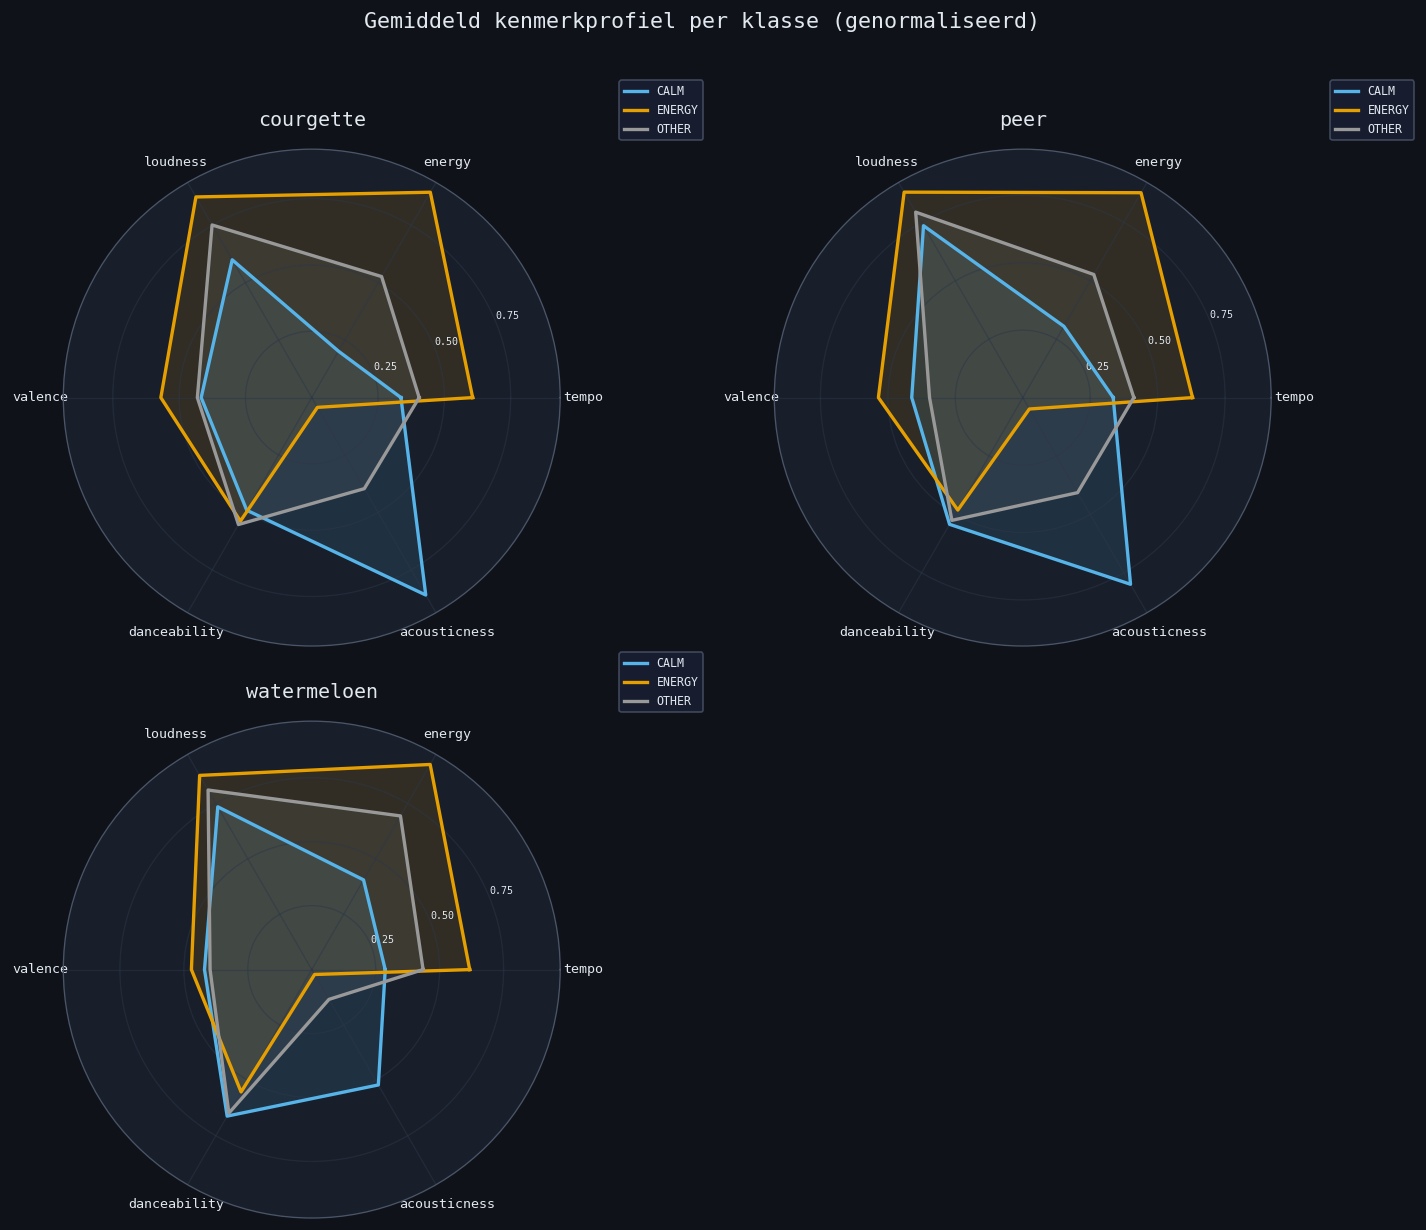

In [15]:
RADAR_FEATURES = ['tempo', 'energy', 'loudness', 'valence', 'danceability', 'acousticness']

# Normaliseer naar [0,1] over alle deelnemers samen voor vergelijkbaarheid
all_songs = pd.concat([df for df, _, _ in results.values()], ignore_index=True)
feat_min  = all_songs[RADAR_FEATURES].min()
feat_max  = all_songs[RADAR_FEATURES].max()


def normalize_radar(df_sub: pd.DataFrame) -> pd.DataFrame:
    return (df_sub[RADAR_FEATURES] - feat_min) / (feat_max - feat_min + 1e-9)


n_feat  = len(RADAR_FEATURES)
angles  = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

n_cols = min(2, len(participants))
n_rows = math.ceil(len(participants) / n_cols)
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows),
    subplot_kw={'projection': 'polar'}, squeeze=False,
)

for idx, codename in enumerate(participants):
    df_c = results[codename][0]
    ax = axes[idx // n_cols][idx % n_cols]
    ax.set_facecolor('#181e2a')

    for cls in CLASS_ORDER:
        subset = df_c[df_c['class'] == cls]
        if len(subset) == 0:
            continue
        means  = normalize_radar(subset).mean().tolist()
        values = means + means[:1]
        ax.plot(angles, values, color=CLASS_COLORS[cls], linewidth=2, label=cls.upper())
        ax.fill(angles, values, color=CLASS_COLORS[cls], alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_FEATURES, fontsize=8)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=6, color='#4a5568')
    ax.tick_params(colors='#e2e8f0')
    ax.set_title(codename, pad=14)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=7)
    ax.grid(color='#2d3748', alpha=0.5)

for idx in range(len(participants), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.suptitle('Gemiddeld kenmerkprofiel per klasse (genormaliseerd)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6b. Feature boxplots per klasse

Detailweergave van de vier belangrijkste kenmerken.
De spreiding binnen een klasse laat zien hoe homogeen de groep is --
een smalle box betekent consistente nummers; een brede box betekent grote variatie.

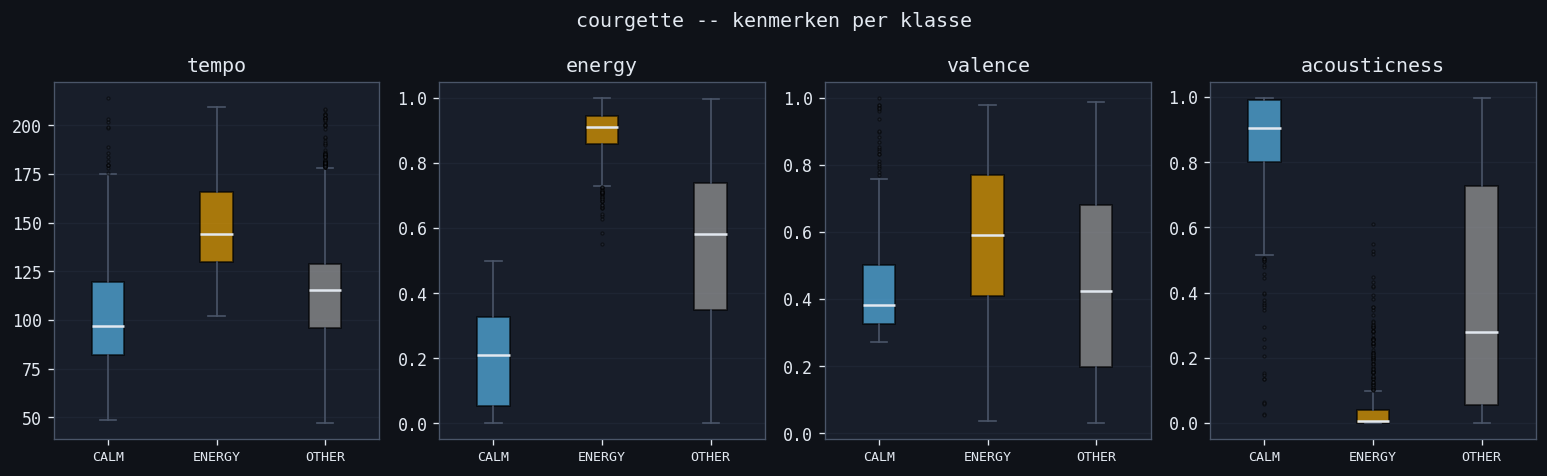

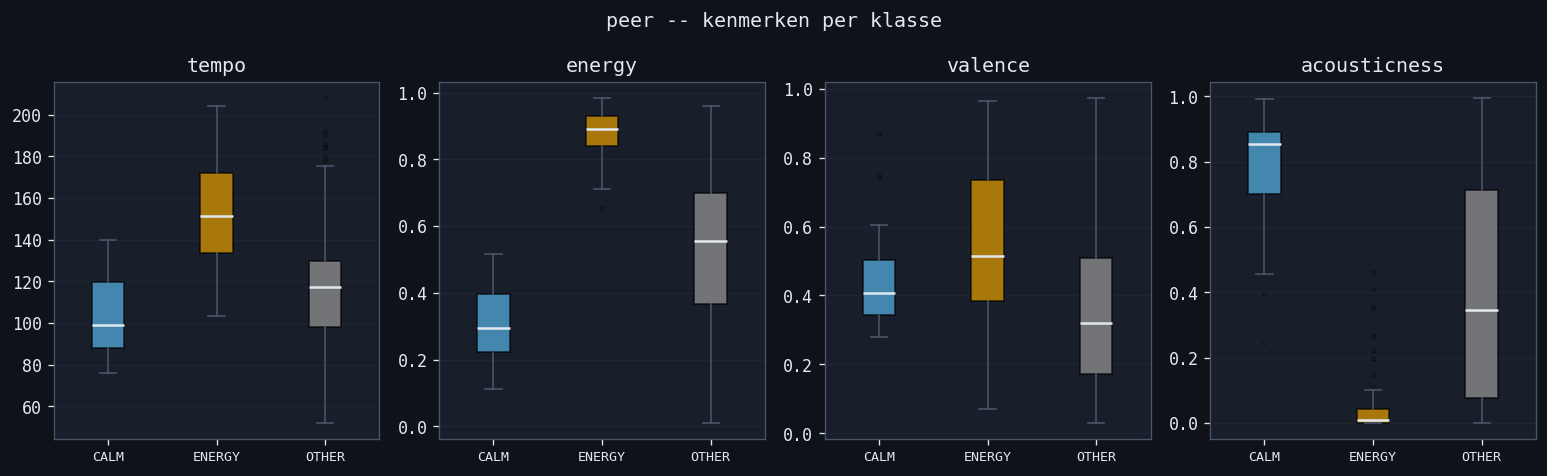

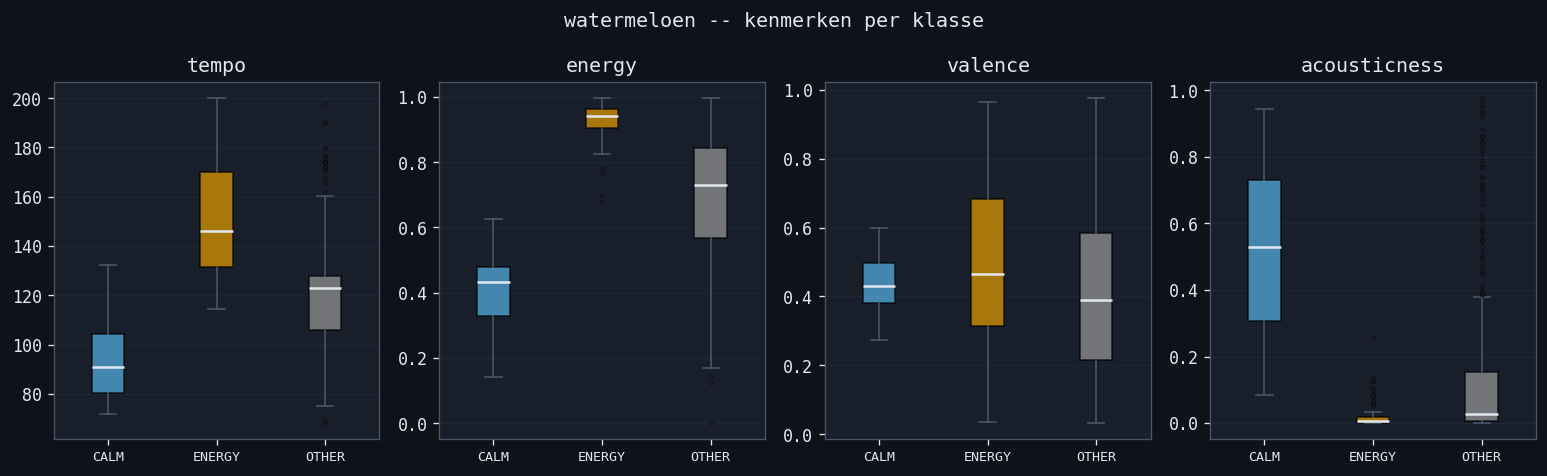

In [16]:
BOX_FEATURES = ['tempo', 'energy', 'valence', 'acousticness']

for codename in participants:
    df_c = results[codename][0]

    fig, axes = plt.subplots(1, len(BOX_FEATURES), figsize=(13, 4))

    for ax, feat in zip(axes, BOX_FEATURES):
        groups = [df_c[df_c['class'] == cls][feat].dropna() for cls in CLASS_ORDER]
        bp = ax.boxplot(
            groups,
            patch_artist=True,
            medianprops={'color': '#e2e8f0', 'linewidth': 1.5},
            whiskerprops={'color': '#4a5568'},
            capprops={'color': '#4a5568'},
            flierprops={'marker': '.', 'markerfacecolor': '#4a5568', 'markersize': 3, 'alpha': 0.5},
        )
        for patch, cls in zip(bp['boxes'], CLASS_ORDER):
            patch.set_facecolor(CLASS_COLORS[cls])
            patch.set_alpha(0.7)

        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([c.upper() for c in CLASS_ORDER], fontsize=8)
        ax.set_title(feat)
        ax.grid(True, axis='y', alpha=0.3)

    fig.suptitle(f'{codename} -- kenmerken per klasse', fontsize=12)
    plt.tight_layout()
    plt.show()